In [1]:
"""Analysis of reasoning token lengths for base model coding inference."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
# --- configuration ---

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# pre-computed stats live here (generated by scripts/compute_stats.py)
OVERFLOW_DIR = Path("../output/token_stats")

# datasets to analyse, grouped by domain.
# each entry: display label → (inference file stem, dataset jsonl path)
DATASETS: dict[str, dict[str, tuple[str, str]]] = {
    "code": {
        "evalplus": ("evalplus_greedy", "code/evalplus.jsonl"),
        "livecodebench": ("livecodebench_greedy", "code/livecodebench.jsonl"),
        "bigcodebench": ("bigcodebench_greedy", "code/bigcodebench.jsonl"),
        "editbench": ("editbench_greedy", "code/editbench.jsonl"),
        "codereval": ("codereval_greedy", "code/codereval.jsonl"),
    },
    "crux": {
        "cruxeval_i": ("cruxeval_i_greedy", "crux/cruxeval_i.jsonl"),
        "cruxeval_o": ("cruxeval_o_greedy", "crux/cruxeval_o.jsonl"),
    },
    "math": {
        "gsm8k": ("gsm8k_greedy", "math/gsm8k.jsonl"),
        "math500": ("math500_greedy", "math/math500.jsonl"),
    },
    "reasoning": {
        "gpqa": ("gpqa_greedy", "reasoning/gpqa.jsonl"),
    },
}

# base models: name → huggingface path + olmo_style flag.
# olmo_style=True means the chat template injects <think> automatically so a
# missing </think> in output indicates the response was truncated.
MODELS: dict[str, dict] = {
    "qwen3-8b": {
        "hf_path": "Qwen/Qwen3-8B",
        "olmo_style": False,
    },
    "olmo-3-7b-think": {
        "hf_path": "allenai/OLMo-3-7B-Think",
        "olmo_style": True,
    },
    "code-nemotron-7b": {
        "hf_path": "nvidia/OpenCodeReasoning-Nemotron-7B",
        "olmo_style": False,
    },
}

# series define a (model, run type) combination.
# file_suffix is appended to each dataset's base file stem when loading stats
# (e.g. "_baseline" turns "evalplus_greedy" → "evalplus_greedy_baseline").
SERIES: dict[str, dict] = {
    "qwen3_greedy": {
        "label": "Qwen3-8B\n(greedy)",
        "model_key": "qwen3-8b",
        "file_suffix": "_baseline",
        "colour": "#2196F3",
    },
    "olmo_greedy": {
        "label": "OLMo3-7B\n(greedy)",
        "model_key": "olmo-3-7b-think",
        "file_suffix": "_baseline",
        "colour": "#FF9800",
    },
    "code_nemotron_greedy": {
        "label": "Code-Nemotron-7B\n(greedy)",
        "model_key": "code-nemotron-7b",
        "file_suffix": "_baseline",
        "colour": "#4CAF50",
    },
}

# human-readable subplot titles for each dataset
DATASET_DISPLAY_NAMES: dict[str, str] = {
    "evalplus": "EvalPlus (simple coding)",
    "livecodebench": "LiveCodeBench (complex coding)",
    "bigcodebench": "BigCodeBench (coding)",
    "editbench": "EditBench (code editing)",
    "codereval": "CoderEval (coding)",
    "cruxeval_i": "CRUXEval-I (input prediction)",
    "cruxeval_o": "CRUXEval-O (output prediction)",
    "gsm8k": "GSM8K (simple math)",
    "math500": "MATH-500 (challenging math)",
    "gpqa": "GPQA (expert Q&A)",
}

# colours used when group_by="model" — one colour per dataset for the violins
DATASET_COLOURS: dict[str, str] = {
    "evalplus": "#2196F3",
    "livecodebench": "#9C27B0",
    "bigcodebench": "#FF9800",
    "editbench": "#00BCD4",
    "codereval": "#795548",
    "cruxeval_i": "#E91E63",
    "cruxeval_o": "#F44336",
    "gsm8k": "#009688",
    "math500": "#FF5722",
    "gpqa": "#607D8B",
}

# max generation tokens used for all runs
MAX_TOKENS = 32768

In [3]:
def load_series_results(
    series_keys: list[str],
    datasets: dict[str, dict[str, tuple[str, str]]],
) -> dict[str, dict[str, dict[str, list]]]:
    """Load pre-computed token stats from output/token_stats/.

    Run scripts/compute_stats.py first to generate these files.
    Missing files are skipped with a warning.

    Returns a nested dict: series_key → ds_label → {token_counts, truncated, overflow, budget_pct, pass_at_1}.
    """
    # flatten the nested datasets dict to {label: (file_stem, jsonl_path)}
    flat_datasets: dict[str, tuple[str, str]] = {
        label: entry
        for domain_ds in datasets.values()
        for label, entry in domain_ds.items()
    }

    results: dict[str, dict[str, dict[str, list]]] = {}
    for series_key in series_keys:
        results[series_key] = {}
        model_key = SERIES[series_key]["model_key"]
        file_suffix = SERIES[series_key]["file_suffix"]

        for ds_label, (ds_file, _) in flat_datasets.items():
            # stats are stored per model, with the same filename as the inference run
            stats_path = OVERFLOW_DIR / model_key / f"{ds_file}{file_suffix}.json"
            if not stats_path.exists():
                print(
                    f"  [skip] missing {stats_path} "
                    f"— run scripts/compute_stats.py first"
                )
                continue

            with open(stats_path) as f:
                stats = json.load(f)

            results[series_key][ds_label] = {
                "token_counts": stats["token_counts"],
                "truncated": stats["truncated"],
                # older cache files may not have overflow; fall back to truncated
                "overflow": stats.get("overflow", stats["truncated"]),
                "budget_pct": stats["budget_pct"],
                "pass_at_1": stats["pass_at_1"],
            }

            n_trunc = sum(stats["truncated"])
            n_overflow = sum(stats.get("overflow", stats["truncated"]))
            counts = stats["token_counts"]
            pcts = stats["budget_pct"]
            pass_at_1 = stats["pass_at_1"]
            print(
                f"  {series_key} / {ds_label}: "
                f"n={len(counts)}, "
                f"median={int(np.median(counts)):,} tokens, "
                f"median budget={np.median(pcts):.1f}%, "
                f"pass@1={100 * pass_at_1:.1f}%, "
                f"reasoning overflow={n_trunc} ({100 * n_trunc / len(counts):.1f}%), "
                f"general overflow={n_overflow} ({100 * n_overflow / len(counts):.1f}%)"
            )

    return results


# load all series upfront — individual plot calls will select the subset they need
print("loading results...")
all_results = load_series_results(
    series_keys=list(SERIES.keys()),
    datasets=DATASETS,
)

loading results...
  qwen3_greedy / evalplus: n=542, median=2,185 tokens, median budget=6.7%, pass@1=64.8%, reasoning overflow=49 (9.0%), general overflow=49 (9.0%)
  qwen3_greedy / livecodebench: n=342, median=16,299 tokens, median budget=50.6%, pass@1=nan%, reasoning overflow=98 (28.7%), general overflow=98 (28.7%)
  qwen3_greedy / bigcodebench: n=1140, median=4,609 tokens, median budget=14.1%, pass@1=nan%, reasoning overflow=237 (20.8%), general overflow=238 (20.9%)
  qwen3_greedy / editbench: n=540, median=2,336 tokens, median budget=7.4%, pass@1=nan%, reasoning overflow=106 (19.6%), general overflow=106 (19.6%)
  [skip] missing ../output/token_stats/qwen3-8b/codereval_greedy_baseline.json — run scripts/compute_stats.py first
  [skip] missing ../output/token_stats/qwen3-8b/cruxeval_i_greedy_baseline.json — run scripts/compute_stats.py first
  [skip] missing ../output/token_stats/qwen3-8b/cruxeval_o_greedy_baseline.json — run scripts/compute_stats.py first
  [skip] missing ../output

In [4]:
def _draw_violin_axes(
    ax: plt.Axes,
    data_per_violin: list[list],
    labels: list[str],
    colours: list[str],
    annotations: list[str],
    median_labels: list[str],
    title: str,
    ylabel: str,
    hline: float | None,
    ylim: tuple | None,
    yformatter,
) -> None:
    """Draw violin plots for one subplot, with per-violin annotations.

    Positions violins at integer x positions, colours each by its entry in
    colours, writes the median value to the right of the median line inside
    the plot, and writes overflow stats below the axis for each violin.
    """
    positions = list(range(1, len(data_per_violin) + 1))

    parts = ax.violinplot(
        data_per_violin,
        positions=positions,
        showmedians=True,
        showextrema=True,
    )

    for pc, colour in zip(parts["bodies"], colours):
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)

    # label the median line to the right of each violin; 0.5 units clears the body
    for x_pos, data, median_label in zip(positions, data_per_violin, median_labels):
        ax.text(
            x_pos + 0.2,
            np.median(data),
            median_label,
            ha="left",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

    # write overflow stats below the x-axis for each violin;
    # -0.25 in axes coords gives enough clearance for 2 lines at fontsize 20
    for colour, x_pos, annotation in zip(colours, positions, annotations):
        ax.text(
            x_pos,
            -0.25,
            annotation,
            ha="center",
            va="top",
            fontsize=20,
            fontweight="bold",
            color=colour,
            transform=ax.get_xaxis_transform(),
        )

    if hline is not None:
        ax.axhline(hline, color="red", linestyle="--", linewidth=1.2)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        labels,
        rotation=0,
        ha="center",
        fontsize=20,
    )
    ax.set_title(title, fontsize=30, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=20)

    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(bottom=0)

    if yformatter is not None:
        ax.yaxis.set_major_formatter(yformatter)

    ax.tick_params(axis="y", labelsize=20)
    ax.grid(axis="y", alpha=0.3)


def _build_plot(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    group_by: str,
    get_data: callable,
    get_annotation: callable,
    get_median_label: callable,
    ylabel: str,
    hline: float | None,
    ylim: tuple | None,
    yformatter,
    save_path: "Path",
) -> None:
    """Build and save a violin plot figure, stacked vertically.

    group_by="dataset": one subplot per dataset, one violin per series/model.
    group_by="model":   one subplot per series/model, one violin per dataset.
    Rows with no loaded data are silently skipped so missing stats files don't
    cause a crash.
    """
    # flatten all dataset labels in order
    all_ds_labels: list[str] = [
        ds_label for domain_ds in datasets.values() for ds_label in domain_ds
    ]

    # pre-collect each row's data so we can filter out rows with no results
    # before creating the figure (violinplot errors on empty datasets)
    rows: list[dict] = []

    if group_by == "dataset":
        for ds_label in all_ds_labels:
            row: dict = {
                "title": DATASET_DISPLAY_NAMES[ds_label],
                "labels": [],
                "colours": [],
                "data": [],
                "annotations": [],
                "median_labels": [],
            }
            for series_key in series_keys:
                ds_results = loaded_results.get(series_key, {}).get(ds_label)
                if ds_results is None:
                    continue
                row["labels"].append(SERIES[series_key]["label"])
                row["colours"].append(SERIES[series_key]["colour"])
                row["data"].append(get_data(ds_results))
                row["annotations"].append(get_annotation(ds_results))
                row["median_labels"].append(get_median_label(ds_results))
            if row["data"]:
                rows.append(row)

    elif group_by == "model":
        for series_key in series_keys:
            row = {
                "title": SERIES[series_key]["label"].replace("\n", " "),
                "labels": [],
                "colours": [],
                "data": [],
                "annotations": [],
                "median_labels": [],
            }
            for ds_label in all_ds_labels:
                ds_results = loaded_results.get(series_key, {}).get(ds_label)
                if ds_results is None:
                    continue
                row["labels"].append(DATASET_DISPLAY_NAMES[ds_label])
                row["colours"].append(DATASET_COLOURS[ds_label])
                row["data"].append(get_data(ds_results))
                row["annotations"].append(get_annotation(ds_results))
                row["median_labels"].append(get_median_label(ds_results))
            if row["data"]:
                rows.append(row)

    else:
        raise ValueError(f"group_by must be 'dataset' or 'model', got {group_by!r}")

    if not rows:
        print(f"  [skip] no data to plot for {save_path.name}")
        return

    n_rows = len(rows)
    n_violins = len(all_ds_labels) if group_by == "model" else len(series_keys)

    # 2 inches per violin width; 0.6 per violin for row height gives enough
    # vertical space for the plot body and the per-violin annotations below
    col_width = max(8, n_violins * 2.0)
    row_height = max(5, n_violins * 0.6)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=1,
        figsize=(col_width, row_height * n_rows),
        sharey=True,
        squeeze=False,
    )

    for row_idx, row in enumerate(rows):
        _draw_violin_axes(
            ax=axes[row_idx][0],
            data_per_violin=row["data"],
            labels=row["labels"],
            colours=row["colours"],
            annotations=row["annotations"],
            median_labels=row["median_labels"],
            title=row["title"],
            ylabel=ylabel,
            hline=hline,
            ylim=ylim,
            yformatter=yformatter,
        )

    # h_pad controls the vertical gap between subplots, giving the below-axis
    # annotation text room to breathe before the next subplot's title
    fig.tight_layout(h_pad=6)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved {save_path}")
    plt.show()


def _make_annotation(ds_results: dict) -> str:
    """Build the per-violin annotation string showing overflow rates."""
    truncated = ds_results["truncated"]
    overflow = ds_results["overflow"]
    pct_trunc = 100 * sum(truncated) / len(truncated)
    pct_overflow = 100 * sum(overflow) / len(overflow)
    return f"Reasoning →∞ = {pct_trunc:.1f}%\nGeneral →∞ = {pct_overflow:.1f}%"


def plot_token_lengths(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    save_path: "Path",
    group_by: str = "dataset",
    max_tokens: int = MAX_TOKENS,
) -> None:
    """Plot violin distributions of raw reasoning token counts.

    One subplot per group (dataset or model), stacked vertically.  A red
    dashed line marks the generation cap (max_tokens).  group_by controls
    whether subplots group results by dataset (violin per series) or by model
    (violin per dataset).
    """

    def get_data(ds_results: dict) -> list[int]:
        return ds_results["token_counts"]

    def get_annotation(ds_results: dict) -> str:
        return _make_annotation(ds_results)

    def get_median_label(ds_results: dict) -> str:
        return f"{int(np.median(ds_results['token_counts'])):,}"

    _build_plot(
        series_keys=series_keys,
        loaded_results=loaded_results,
        datasets=datasets,
        group_by=group_by,
        get_data=get_data,
        get_annotation=get_annotation,
        get_median_label=get_median_label,
        ylabel="Reasoning tokens",
        hline=max_tokens,
        ylim=None,
        yformatter=mticker.FuncFormatter(lambda x, _: f"{int(x):,}"),
        save_path=save_path,
    )


def plot_budget_pct(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    save_path: "Path",
    group_by: str = "dataset",
) -> None:
    """Plot violin distributions of reasoning as % of available token budget.

    Truncated responses are pinned at 100% so they visually hit the budget
    ceiling.  One subplot per group, stacked vertically.  group_by controls
    whether subplots group results by dataset (violin per series) or by model
    (violin per dataset).
    """

    def get_data(ds_results: dict) -> list[float]:
        return ds_results["budget_pct"]

    def get_annotation(ds_results: dict) -> str:
        return _make_annotation(ds_results)

    def get_median_label(ds_results: dict) -> str:
        return f"{np.median(ds_results['budget_pct']):.1f}%"

    _build_plot(
        series_keys=series_keys,
        loaded_results=loaded_results,
        datasets=datasets,
        group_by=group_by,
        get_data=get_data,
        get_annotation=get_annotation,
        get_median_label=get_median_label,
        ylabel="% of token budget used for reasoning",
        hline=100,
        ylim=(0, 105),
        yformatter=mticker.PercentFormatter(),
        save_path=save_path,
    )

saved ../figures/02_budget_used_for_reasoning.png


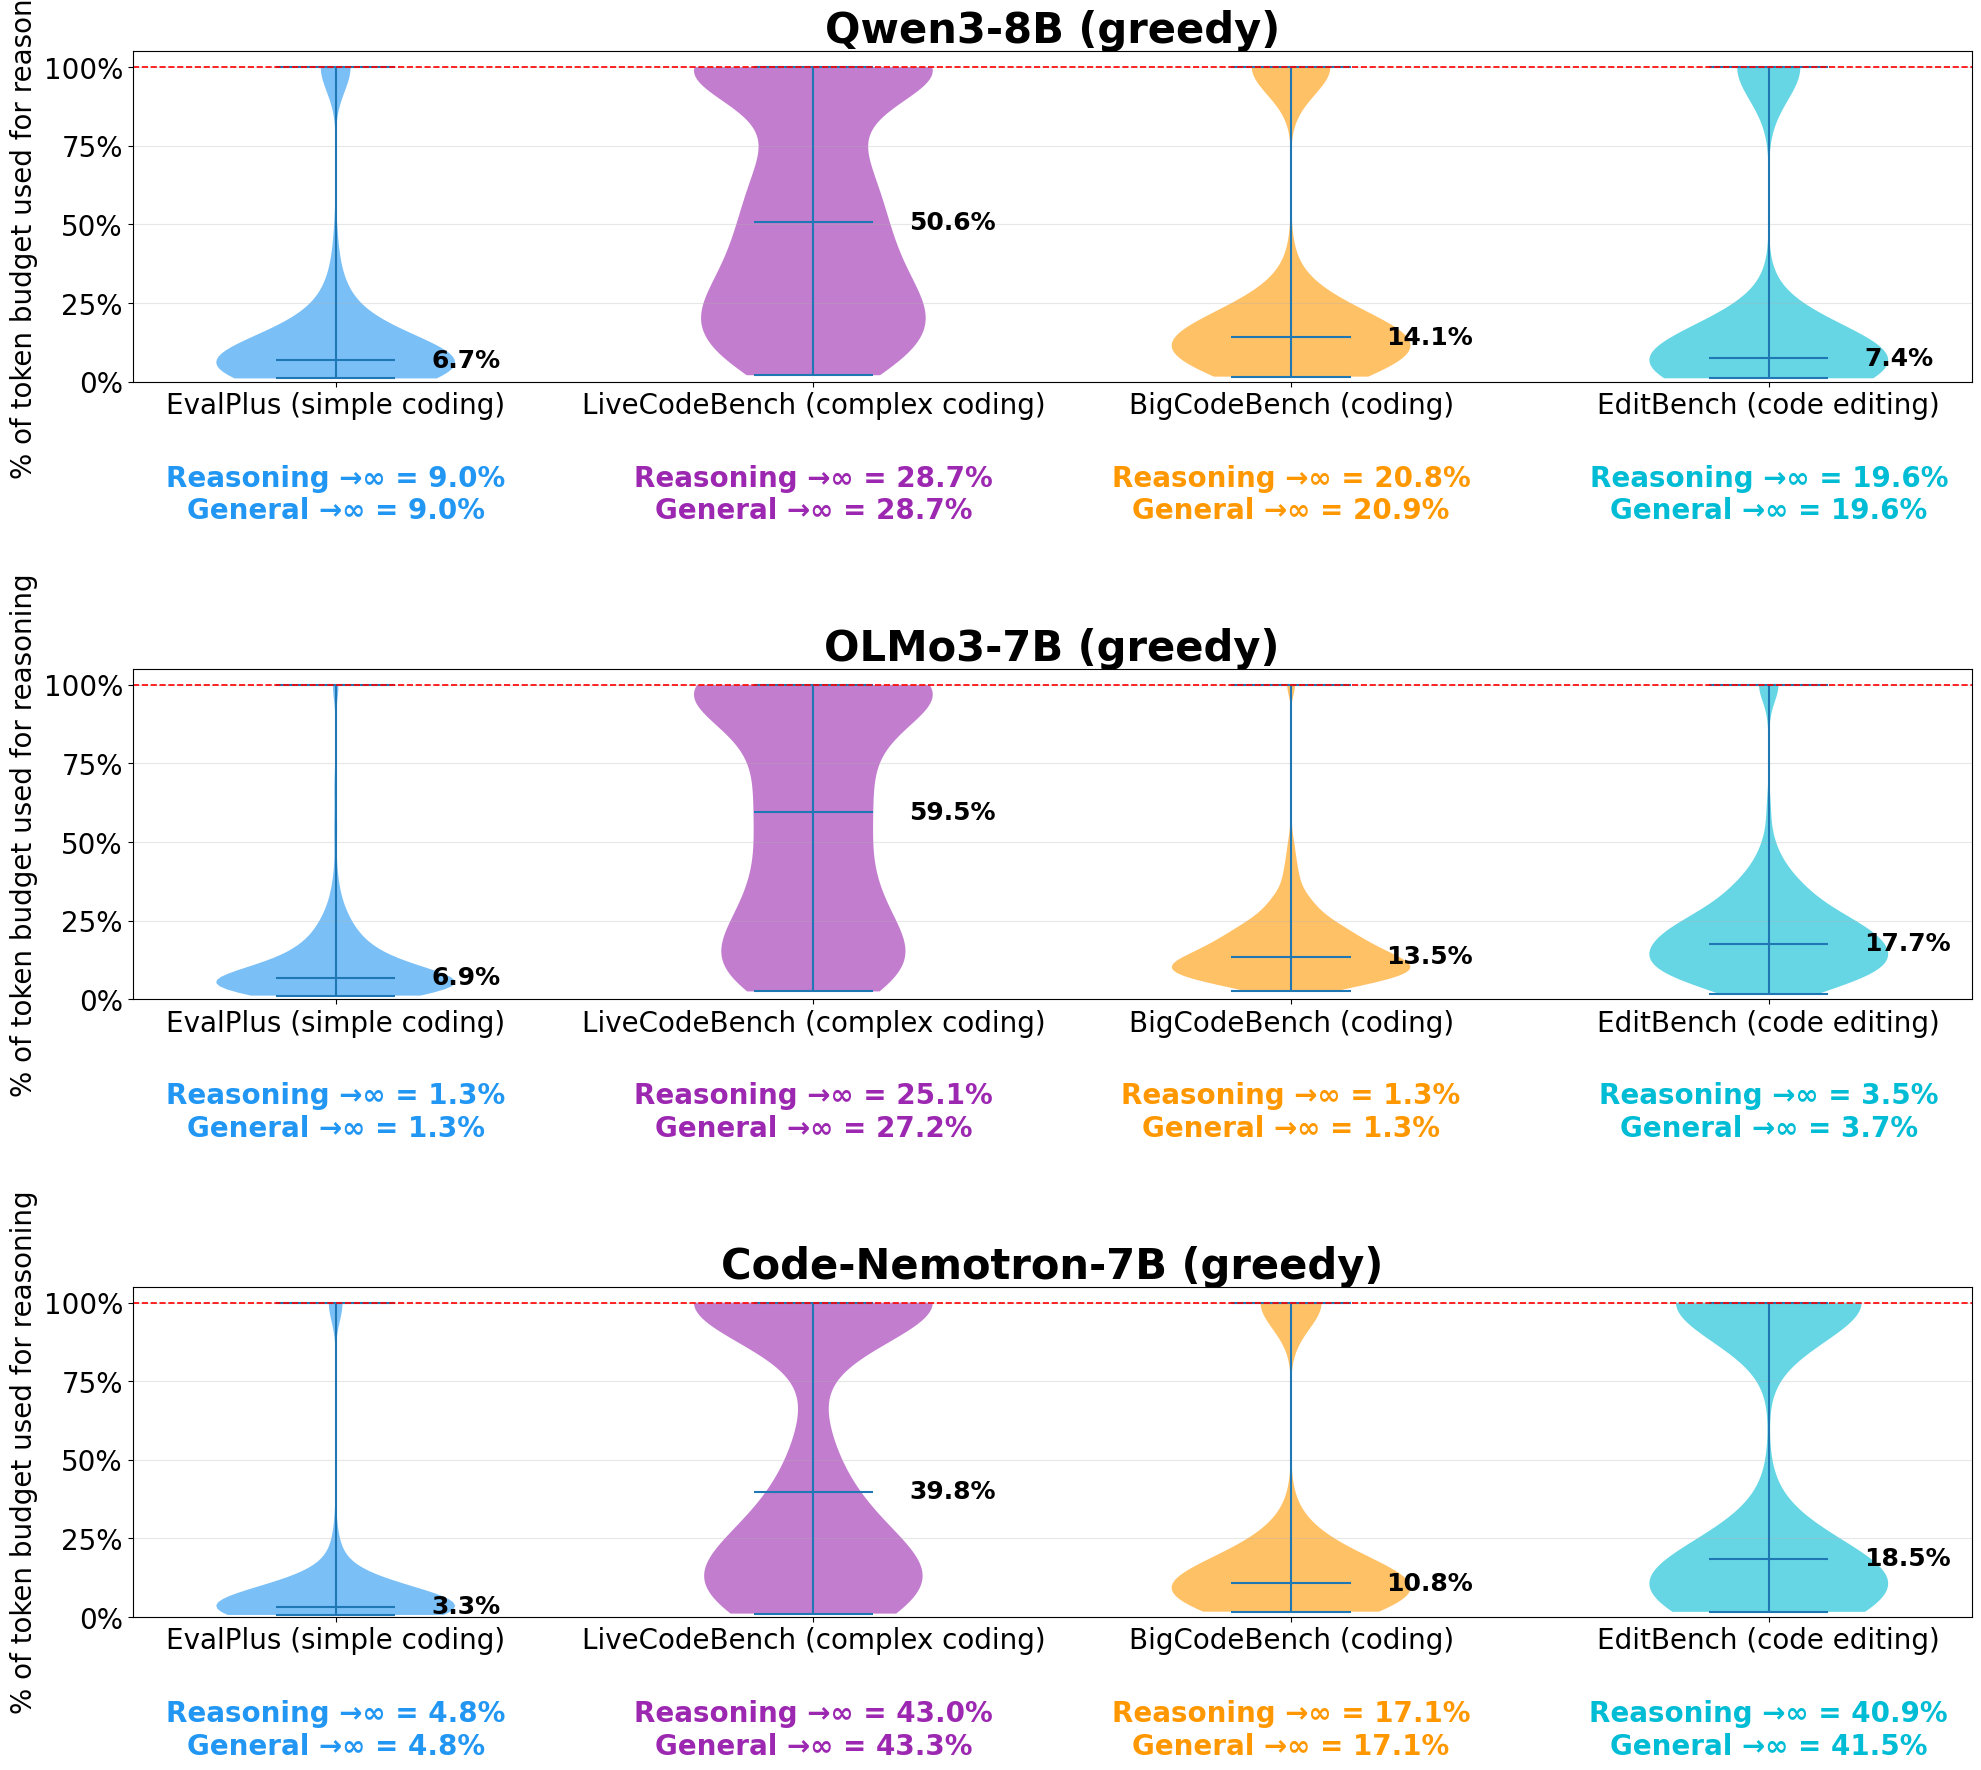

In [5]:
# --- base model comparison: Qwen3-8B vs OLMo3-7B vs Code-Nemotron-7B, all greedy ---
# shows how the three base models differ in reasoning length across all datasets.
# group_by="dataset": one subplot per dataset, one violin per model (good for comparing models on a task).
# group_by="model": one subplot per model, one violin per dataset (good for seeing how one model varies).

BASE_SERIES = ["qwen3_greedy", "olmo_greedy", "code_nemotron_greedy"]

plot_budget_pct(
    series_keys=BASE_SERIES,
    loaded_results=all_results,
    datasets=DATASETS,
    group_by="model",
    save_path=FIGURES_DIR / "02_budget_used_for_reasoning.png",
)